In [126]:
# базовые
from datetime import datetime
import os

# библиотеки ML
import torch
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score
)


# работа с данными
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.dates as mdates
from datetime import datetime


# архитектура
from pinn_architecture import PINN_Mill

In [32]:
def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs,
        inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True
    )[0]

In [33]:
Ore_Density=2800.0
Liquid_Density=1300.0

A_pulp=2.12
Mill_Length=4.5

D_coeff=0.001

S_max=500.0

eps_ref=0.30
M_ref=6000.0
K_0=0.0015

# LOSS

In [34]:
def loss_pde(model, t_pde, z_pde, Fm_pde, Fl_pde):
    eps, S = model(t_pde, z_pde, Fm_pde, Fl_pde)
    deps_dt = grad(eps, t_pde)
    deps_dz = grad(eps, z_pde)
    d2eps_dz2 = grad(deps_dz, z_pde)
    dS_dt = grad(S, t_pde)
    dS_dz = grad(S, z_pde)
    d2S_dz2 = grad(dS_dz, z_pde)
    # скорость пульпы
    Qs = Fm_pde / Ore_Density
    Ql = Fl_pde / Liquid_Density
    u_s = (Qs + Ql) / A_pulp
    # масса твердого в мельнице
    M_solid_total = Ore_Density * A_pulp * torch.mean(eps) * Mill_Length
    # кинетика
    mass_factor = M_ref / (M_solid_total + 1e-8)
    eps_factor = eps / eps_ref
    k = K_0 * mass_factor * eps_factor
    # k = K_0
    # PDE для eps
    r_eps = deps_dt + u_s * deps_dz - D_coeff * d2eps_dz2
    r_S = dS_dt + u_s * dS_dz - D_coeff * d2S_dz2 - k * (S_max - S)

    loss = torch.mean(r_eps**2) + torch.mean(r_S**2)
    return loss

In [35]:
def loss_bc(model, t_bc, z_bc, Fm_bc, Fl_bc, S_in_bc,):
    eps_bc, S_bc = model(t_bc, z_bc, Fm_bc, Fl_bc)
    Qs_bc = Fm_bc / Ore_Density
    Ql_bc = Fl_bc / Liquid_Density
    eps_inlet = Qs_bc / (Qs_bc + Ql_bc + 1e-8)
    bc_eps = eps_bc - eps_inlet
    bc_S = S_bc - S_in_bc
    loss = torch.mean(bc_eps**2) + torch.mean(bc_S**2)
    return loss

In [36]:
def loss_ic(model, t_ic, z_ic, Fm_ic, Fl_ic, eps0_ic, S0_ic,):
    eps_ic_pred, S_ic_pred = model(t_ic, z_ic, Fm_ic, Fl_ic)
    loss = torch.mean((eps_ic_pred - eps0_ic)**2) + torch.mean((S_ic_pred - S0_ic)**2)
    return loss

In [37]:
def loss_data(model, t_real=None, z_real=None, Fm_real=None, Fl_real=None, S_real=None,):
    loss = torch.tensor(0.0, device=t_pde.device)
    if S_real is not None:
        eps_pred, S_pred = model(t_real, z_real, Fm_real, Fl_real)
        loss = torch.mean((S_pred - S_real)**2)
    return loss

In [38]:
def total_loss(
        loss_pde,
        loss_bc,
        loss_ic,
        loss_data,
        lambda_pde=1.0,
        lambda_bc=10.0,
        lambda_ic=10.0,
        lambda_data=100.0
        ):
        loss = lambda_pde * loss_pde + lambda_bc * loss_bc + lambda_ic * loss_ic + lambda_data * loss_data

        return loss, loss_pde, loss_bc, loss_ic, loss_data

# data

In [112]:
df = pd.read_csv("data_final.csv")

In [113]:
df = df.sort_values(by="average_time").reset_index(drop=True)
cols_to_interp = ["Q_bauxite_[t/h]", "Q_liquid_mill13_[m3/h]", "residence_time_[s]", "V_[m/s]"]
df[cols_to_interp] = df[cols_to_interp].interpolate(method="linear", limit_direction="both")

In [ ]:
# исходные физические данные
Fm = df["Q_bauxite_[t/h]"].values.reshape(-1, 1)
Fl = df["Q_liquid_mill13_[m3/h]"].values.reshape(-1, 1)
S = df["S_[m2/kg]"].values.reshape(-1, 1)
t = df['residence_time_[s]'].values.reshape(-1, 1)
v = df["V_[m/s]"].values.reshape(-1, 1)
average_time = df['average_time']#.values.reshape(-1, 1)


Fm_train, Fm_test, \
Fl_train, Fl_test, \
S_train, S_test, \
t_train, t_test, \
v_train, v_test, \
average_time_train, average_time_test = train_test_split(
    Fm, Fl, S, t, v, average_time,
    test_size=0.2,
    # random_state=42,
    shuffle=False
)

In [115]:
# tensor train
Fm_real_train = torch.FloatTensor(Fm_train)
Fl_real_train = torch.FloatTensor(Fl_train)
t_real_train = torch.FloatTensor(t_train)
S_real_train = torch.FloatTensor(S_train)

# tensor test
Fm_real_test = torch.FloatTensor(Fm_test)
Fl_real_test = torch.FloatTensor(Fl_test)
t_real_test = torch.FloatTensor(t_test)
S_real_test = torch.FloatTensor(S_test)

In [ ]:
# ==================================================
# вычисление времени пребывания
# ==================================================

Ore_Density = 2800.0
Liquid_Density = 1300.0
Water_Density = 1000
A_pulp = 1.89
Mill_Length = 4.5

Qs_train = Fm_real_train * 0.9 * 1000 / Ore_Density
Ql_train = (Fl_real_train / Liquid_Density) + (Fm_real_train * 0.1 * 1000 / Water_Density) 

u_train = (Qs_train + Ql_train) / (A_pulp * 3600)

t_real_train = Mill_Length / (u_train + 1e-8)
t_real_train.requires_grad_(True)

Qs_test = Fm_real_test / Ore_Density
Ql_test = Fl_real_test / Liquid_Density

u_test = (Qs_test + Ql_test) / A_pulp

t_real_test = Mill_Length / (u_test + 1e-8)
t_real_test.requires_grad_(True)

# ==================================================
# координата выхода мельницы
# ==================================================

z_real_train = torch.full(
    (len(Fm_train), 1),
    Mill_Length,
    requires_grad=True
)

z_real_test = torch.full(
    (len(Fm_test), 1),
    Mill_Length,
    requires_grad=True
)

In [101]:
N_pde = 10
t_pde, z_pde, Fm_pde, Fl_pde = [], [], [], []
for fm, fl, t_, v_ in zip(Fm_real_train, Fl_real_train, t_real_train, v_train):
    for i in range(N_pde):
        t_cur = torch.rand(1) * t_
        t_pde.append([t_])
        z_pde.append([t_cur.detach() * v_])
        Fm_pde.append([fm])
        Fl_pde.append([fl])

t_pde, z_pde, Fm_pde, Fl_pde = torch.Tensor(t_pde), torch.Tensor(z_pde), torch.Tensor(Fm_pde), torch.Tensor(Fl_pde) 

In [102]:
# PDE
N_pde = 500
t_pde = torch.rand(N_pde, 1, requires_grad=True) * t.max()
z_pde = Mill_Length * torch.rand(N_pde, 1, requires_grad=True)
idx = torch.randint(
    0,
    len(Fm_real_train),
    (N_pde,)
)

Fm_pde = Fm_real_train[idx]
Fl_pde = Fl_real_train[idx]

In [108]:
# BC
N_bc = 200
t_bc = torch.rand(N_bc, 1, requires_grad=True)
z_bc = torch.zeros(N_bc, 1, requires_grad=True)
idx = torch.randint(0, len(Fm_real_train), (N_bc,))
Fm_bc = Fm_real_train[idx]
Fl_bc = Fl_real_train[idx]
S_in_bc = torch.full((N_bc, 1), 5.0)

# -----------
# BC1
t_bc1, z_bc1, Fm_bc1, Fl_bc1, S_bc1 = [], [], [], [], []
for fm, fl, t_ in zip(Fm_real_train, Fl_real_train, t_real_train):
    t_bc1.append([0])
    z_bc1.append([0])
    Fm_bc1.append([fm])
    Fl_bc1.append([fl])
    S_bc1.append([1])

# -----------
# BC2
t_bc2, z_bc2, Fm_bc2, Fl_bc2, S_bc2 = [], [], [], [], []
for fm, fl, t_, s in zip(Fm_real_train, Fl_real_train, t_real_train, S_real_train):
    t_bc2.append([t_])
    z_bc2.append([4.5])
    Fm_bc2.append([fm])
    Fl_bc2.append([fl])
    S_bc2.append([s])

t_bc1, z_bc1, Fm_bc1, Fl_bc1, S_bc1 = torch.Tensor(t_bc1), torch.Tensor(z_bc1), torch.Tensor(Fm_bc1), torch.Tensor(Fl_bc1), torch.Tensor(S_bc1)
t_bc2, z_bc2, Fm_bc2, Fl_bc2, S_bc2 = torch.Tensor(t_bc2), torch.Tensor(z_bc2), torch.Tensor(Fm_bc2), torch.Tensor(Fl_bc2), torch.Tensor(S_bc2)

In [91]:
Fm_bc1.shape

torch.Size([141])

In [16]:
# IC
N_ic = 200
t_ic = torch.zeros(N_ic, 1, requires_grad=True)
z_ic = Mill_Length * torch.rand(N_ic, 1, requires_grad=True)
idx = torch.randint(0, len(Fm_real_train), (N_ic,))
Fm_ic = Fm_real_train[idx]
Fl_ic = Fl_real_train[idx]
eps0_ic = torch.full((N_ic,1), 0.30)
S0_ic = torch.full((N_ic,1), 50.0)

In [104]:
test_df = pd.DataFrame({'t':t_real_test.detach().squeeze().numpy(),
                        'z': z_real_test.detach().squeeze().numpy(),
                        'Fm': Fm_real_test.detach().squeeze().numpy(),
                        'Fl': Fl_real_test.detach().squeeze().numpy(),
                        'S': S_real_test.detach().squeeze().numpy(),
                        'date':average_time_test})

In [105]:
test_df.to_csv('test_data_not_shuffled.csv')

In [32]:
test_df.to_csv('test_data.csv')

# visualization

In [20]:
def loss_visualization():
    plt.figure(figsize=(10, 6), dpi=120)
    plt.plot(history_total, label='total')
    plt.plot(history_data, label='data')
    plt.plot(history_pde, label='pde')
    plt.plot(history_bc, label='bc')
    plt.plot(history_ic, label='ic')
    plt.title('Training loss history', fontsize=14)
    plt.xlabel('Iteration / Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.yscale('log')
    plt.legend(frameon=True, fontsize=11)
    plt.tight_layout()
    plt.show()

In [21]:
def testing_vis():
    _, preds = model(t_real_train, z_real_train, Fm_real_train, Fl_real_train)
    plt.figure(figsize=(6, 4), dpi=150)
    plt.plot(preds.detach().numpy(), c='r', label='Предсказания')
    plt.plot(S_real_train, label='Реальные данные')
    plt.title("Предсказания на train данных")
    plt.ylabel("Удельная поверхность (S)")
    plt.xlabel("Номер пробы")
    plt.legend()
    plt.show()
    
    _, preds = model(t_real_test, z_real_test, Fm_real_test, Fl_real_test)
    plt.figure(figsize=(6, 4), dpi=150)
    plt.plot(preds.detach().numpy(), c='r', label='Предсказания')
    plt.plot(S_real_test, label='Реальные данные')
    plt.title("Предсказания на test данных")
    plt.ylabel("Удельная поверхность (S)")
    plt.axhline(350,
            linestyle='--', label='Smax')

    plt.axhline(210,
            linestyle='--', label='Smin')
    plt.xlabel("Номер пробы")
    plt.legend()
    plt.show()

# training

## 1st variant

Epoch      0 | Total=2702838.500000 | PDE=0.163069 | BC=55603.667969 | IC=36482.769531 | DATA=17819.740234
Epoch    100 | Total=1448608.250000 | PDE=0.218698 | BC=297.081116 | IC=769.500610 | DATA=14379.421875
Epoch    200 | Total=1248548.000000 | PDE=0.273704 | BC=14.396822 | IC=1705.255493 | DATA=12313.512695
Epoch    300 | Total=1156979.875000 | PDE=0.253864 | BC=56.266430 | IC=1416.900635 | DATA=11422.479492
Epoch    400 | Total=1103420.500000 | PDE=0.235902 | BC=85.571068 | IC=1302.734985 | DATA=10895.372070
Epoch    500 | Total=956957.937500 | PDE=0.259811 | BC=69.696838 | IC=1393.414795 | DATA=9423.265625
Epoch    600 | Total=1114129.500000 | PDE=0.296737 | BC=162.605042 | IC=1099.848877 | DATA=11015.045898
Epoch    700 | Total=1026467.812500 | PDE=0.329441 | BC=532.385803 | IC=486.914001 | DATA=10162.745117
Epoch    800 | Total=950499.937500 | PDE=1.588703 | BC=367.644562 | IC=570.992920 | DATA=9411.120117
Epoch    900 | Total=997632.500000 | PDE=3.765349 | BC=445.727631 | IC=3

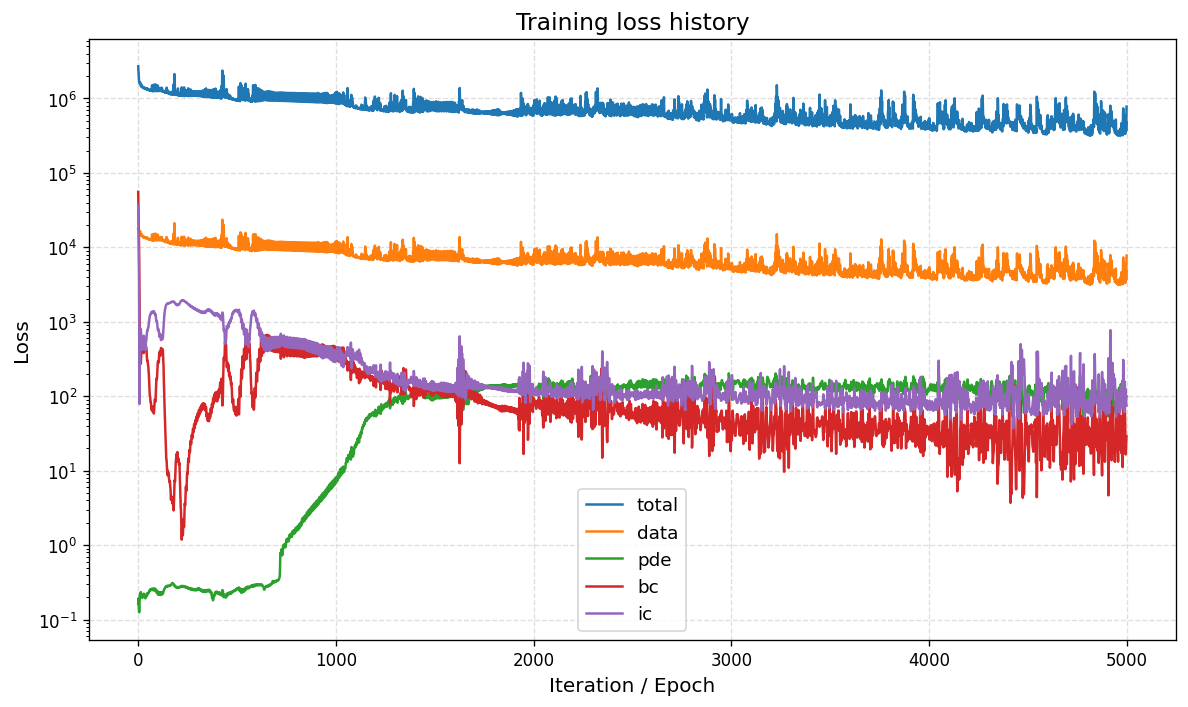

In [64]:
model = PINN_Mill()

# === 1ый этап - AdamW ===
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=500
)

history = []

history_total = []
history_pde = []
history_bc = []
history_ic = []
history_data = []
best_loss = float('inf')
epochs = 5000

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    t_real_train = t_real_train.detach().requires_grad_(True)
    z_real_train = z_real_train.detach().requires_grad_(True)

    t_pde = t_pde.detach().requires_grad_(True)
    z_pde = z_pde.detach().requires_grad_(True)

    t_bc = t_bc.detach().requires_grad_(True)
    z_bc = z_bc.detach().requires_grad_(True)

    t_ic = t_ic.detach().requires_grad_(True)
    z_ic = z_ic.detach().requires_grad_(True)


    loss, pde, bc, ic, data = total_loss(
        loss_pde(model, t_pde, z_pde, Fm_pde, Fl_pde),
        loss_bc(model, t_bc, z_bc, Fm_bc, Fl_bc, S_in_bc),
        loss_ic(model, t_ic, z_ic, Fm_ic, Fl_ic, eps0_ic, S0_ic), 
        loss_data(model, t_real_train, z_real_train, Fm_real_train, Fl_real_train, S_real_train),
        lambda_pde=1.0,
        lambda_bc=10.0,
        lambda_ic=10.0,
        lambda_data=100.0
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()
    scheduler.step(loss)

    history_total.append(loss.item())
    history_pde.append(pde.item())
    history_bc.append(bc.item())
    history_ic.append(ic.item())

    if torch.is_tensor(data):
        history_data.append(data.item())
    else:
        history_data.append(data)

    if loss.item() < best_loss:
        best_loss = loss.item()
        timestamp = datetime.now().strftime("%Y-%m-%d_%H")
        filename = f"best_pinn_{timestamp}.pt"
        torch.save(model.state_dict(), filename)

    if epoch % 100 == 0:

        print(
            f'Epoch {epoch:6d} | '
            f'Total={loss.item():.6f} | '
            f'PDE={pde.item():.6f} | '
            f'BC={bc.item():.6f} | '
            f'IC={ic.item():.6f} | '
            f'DATA={data.item():.6f}'
        )

loss_visualization()

In [65]:
# === 2ый этап - LBFGS ===
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=5000,
    history_size=50,
    line_search_fn='strong_wolfe'
)
def closure():

    optimizer_lbfgs.zero_grad()

    loss, pde, bc, ic, data = total_loss(
            loss_pde(model, t_pde, z_pde, Fm_pde, Fl_pde),
            loss_bc(model, t_bc, z_bc, Fm_bc, Fl_bc, S_in_bc),
            loss_ic(model, t_ic, z_ic, Fm_ic, Fl_ic, eps0_ic, S0_ic), 
            loss_data(model, t_real_train, z_real_train, Fm_real_train, Fl_real_train, S_real_train),
            lambda_pde=1.0,
            lambda_bc=10.0,
            lambda_ic=10.0,
            lambda_data=100.0
        )

    loss.backward()
    return loss

loss_lbfgs = optimizer_lbfgs.step(closure)

if loss_lbfgs.item() < best_loss:
    best_loss = loss_lbfgs.item()
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
    filename = f"best_pinn_lbfgs_{timestamp}.pt"
    torch.save(model.state_dict(), filename)

## 2d variant

/Users/anna/Desktop/uni/PINN/venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  current = float(metrics)


Epoch      0 | Total=18161860.000000 | PDE=0.081923 | BC=56830.945312 | IC=37450.851562 | DATA=18067.578125
Epoch    100 | Total=17389212.000000 | PDE=0.291349 | BC=415.664978 | IC=636.809509 | DATA=17388.160156
Epoch    200 | Total=12585837.000000 | PDE=0.272889 | BC=628.291809 | IC=445.522980 | DATA=12584.762695
Epoch    300 | Total=11700289.000000 | PDE=0.308479 | BC=18.698919 | IC=1687.109863 | DATA=11698.583008
Epoch    400 | Total=11730760.000000 | PDE=0.304383 | BC=44.978504 | IC=1511.199341 | DATA=11729.204102
Epoch    500 | Total=11256755.000000 | PDE=0.298177 | BC=42.745934 | IC=1527.145508 | DATA=11255.184570
Epoch    600 | Total=11116586.000000 | PDE=0.302239 | BC=29.253130 | IC=1615.072388 | DATA=11114.942383
Epoch    700 | Total=11586350.000000 | PDE=0.284579 | BC=200.077881 | IC=1021.567810 | DATA=11585.127930
Epoch    800 | Total=11772069.000000 | PDE=0.292721 | BC=52.977432 | IC=1473.326294 | DATA=11770.542969
Epoch    900 | Total=12679007.000000 | PDE=0.281012 | BC=14

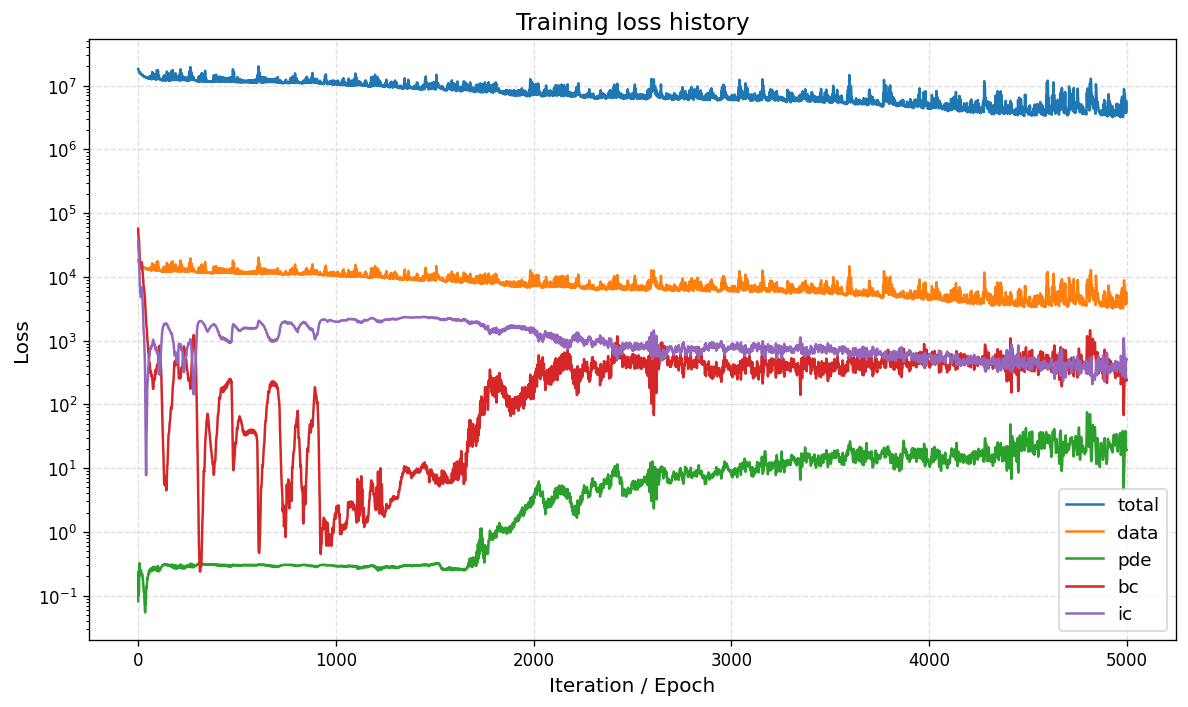

In [19]:
model = PINN_Mill()

# === 1ый этап - AdamW ===
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=500
)

history = []

history_total = []
history_pde = []
history_bc = []
history_ic = []
history_data = []
best_loss = float('inf')
epochs = 5000

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    t_real_train = t_real_train.detach().requires_grad_(True)
    z_real_train = z_real_train.detach().requires_grad_(True)

    t_pde = t_pde.detach().requires_grad_(True)
    z_pde = z_pde.detach().requires_grad_(True)

    t_bc = t_bc.detach().requires_grad_(True)
    z_bc = z_bc.detach().requires_grad_(True)

    t_ic = t_ic.detach().requires_grad_(True)
    z_ic = z_ic.detach().requires_grad_(True)


    loss, pde, bc, ic, data = total_loss(
        loss_pde(model, t_pde, z_pde, Fm_pde, Fl_pde),
        loss_bc(model, t_bc, z_bc, Fm_bc, Fl_bc, S_in_bc),
        loss_ic(model, t_ic, z_ic, Fm_ic, Fl_ic, eps0_ic, S0_ic), 
        loss_data(model, t_real_train, z_real_train, Fm_real_train, Fl_real_train, S_real_train),
        lambda_pde = 0.01,
        lambda_bc = 1,
        lambda_ic = 1,
        lambda_data = 1000
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()
    scheduler.step(loss)

    history_total.append(loss.item())
    history_pde.append(pde.item())
    history_bc.append(bc.item())
    history_ic.append(ic.item())

    if torch.is_tensor(data):
        history_data.append(data.item())
    else:
        history_data.append(data)

    if loss.item() < best_loss:
        best_loss = loss.item()
        timestamp = datetime.now().strftime("%Y-%m-%d_%H")
        filename = f"best_pinn_{timestamp}.pt"
        torch.save(model.state_dict(), filename)

    if epoch % 100 == 0:

        print(
            f'Epoch {epoch:6d} | '
            f'Total={loss.item():.6f} | '
            f'PDE={pde.item():.6f} | '
            f'BC={bc.item():.6f} | '
            f'IC={ic.item():.6f} | '
            f'DATA={data.item():.6f}'
        )

loss_visualization()

## ann

Epoch      0 | Total=18656.003906 | PDE=0.024649 | BC=66447.250000 | IC=45237.207031 | DATA=18656.003906
Epoch    100 | Total=14527.802734 | PDE=0.243571 | BC=423.240112 | IC=624.112854 | DATA=14527.802734
Epoch    200 | Total=14882.361328 | PDE=0.307541 | BC=5.946046 | IC=1837.443481 | DATA=14882.361328
Epoch    300 | Total=14030.484375 | PDE=0.311588 | BC=621.895081 | IC=431.613739 | DATA=14030.484375
Epoch    400 | Total=12202.380859 | PDE=0.319300 | BC=216.815598 | IC=936.031677 | DATA=12202.380859
Epoch    500 | Total=13027.467773 | PDE=0.314532 | BC=236.858047 | IC=907.703491 | DATA=13027.467773
Epoch    600 | Total=11682.493164 | PDE=0.313875 | BC=154.899490 | IC=1075.164062 | DATA=11682.493164
Epoch    700 | Total=12384.424805 | PDE=0.330826 | BC=275.159912 | IC=817.548584 | DATA=12384.424805
Epoch    800 | Total=11730.937500 | PDE=0.327275 | BC=137.509171 | IC=1102.319702 | DATA=11730.937500
Epoch    900 | Total=12173.208008 | PDE=0.348250 | BC=195.568649 | IC=948.127930 | DAT

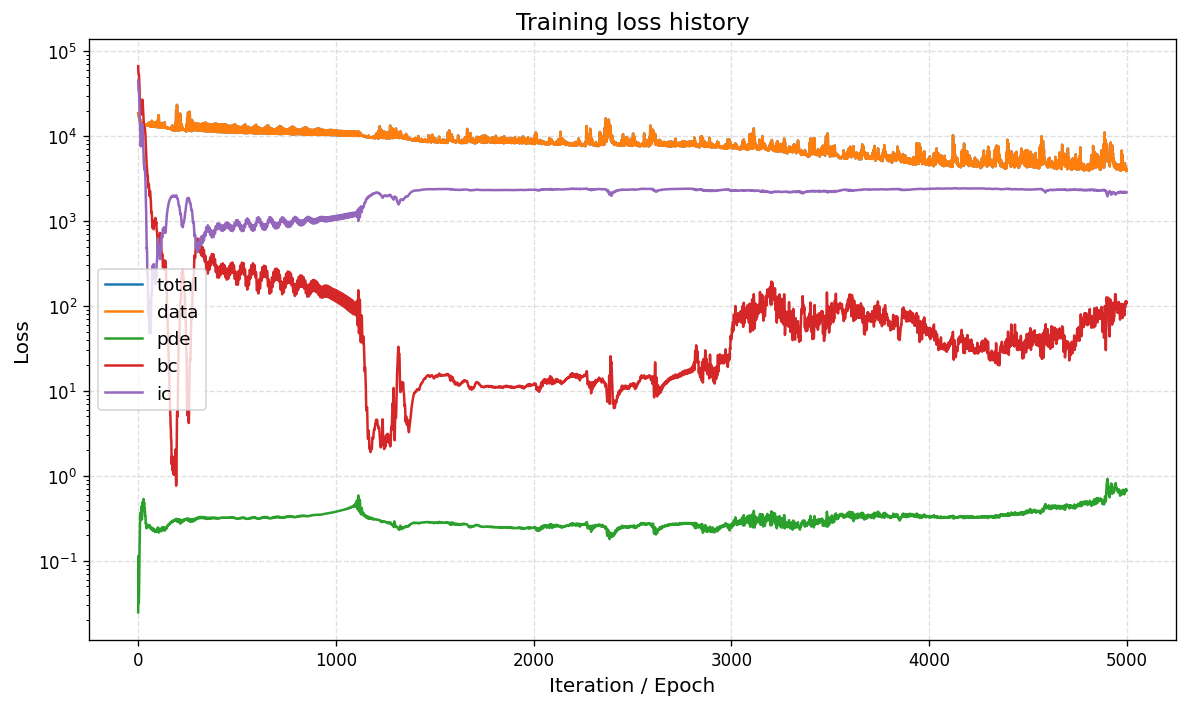

In [22]:
model = PINN_Mill()

# === 1ый этап - AdamW ===
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=500
)

history = []

history_total = []
history_pde = []
history_bc = []
history_ic = []
history_data = []
best_loss = float('inf')
epochs = 5000

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    t_real_train = t_real_train.detach().requires_grad_(True)
    z_real_train = z_real_train.detach().requires_grad_(True)

    t_pde = t_pde.detach().requires_grad_(True)
    z_pde = z_pde.detach().requires_grad_(True)

    t_bc = t_bc.detach().requires_grad_(True)
    z_bc = z_bc.detach().requires_grad_(True)

    t_ic = t_ic.detach().requires_grad_(True)
    z_ic = z_ic.detach().requires_grad_(True)


    loss, pde, bc, ic, data = total_loss(
        loss_pde(model, t_pde, z_pde, Fm_pde, Fl_pde),
        loss_bc(model, t_bc, z_bc, Fm_bc, Fl_bc, S_in_bc),
        loss_ic(model, t_ic, z_ic, Fm_ic, Fl_ic, eps0_ic, S0_ic), 
        loss_data(model, t_real_train, z_real_train, Fm_real_train, Fl_real_train, S_real_train),
        lambda_pde = 0,
        lambda_bc = 0,
        lambda_ic = 0,
        lambda_data = 1
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()
    scheduler.step(loss)

    history_total.append(loss.item())
    history_pde.append(pde.item())
    history_bc.append(bc.item())
    history_ic.append(ic.item())

    if torch.is_tensor(data):
        history_data.append(data.item())
    else:
        history_data.append(data)

    if loss.item() < best_loss:
        best_loss = loss.item()
        timestamp = datetime.now().strftime("%Y-%m-%d_%H")
        filename = f"best_pinn_{timestamp}.pt"
        torch.save(model.state_dict(), filename)

    if epoch % 100 == 0:

        print(
            f'Epoch {epoch:6d} | '
            f'Total={loss.item():.6f} | '
            f'PDE={pde.item():.6f} | '
            f'BC={bc.item():.6f} | '
            f'IC={ic.item():.6f} | '
            f'DATA={data.item():.6f}'
        )

loss_visualization()

## 3d

Epoch      0 | Total=3046914.250000 | PDE=0.266102 | BC=57171.417969 | IC=37703.160156 | DATA=20981.681641
Epoch    100 | Total=1660883.625000 | PDE=0.362716 | BC=260.702057 | IC=832.506775 | DATA=16499.511719
Epoch    200 | Total=1622985.375000 | PDE=0.364341 | BC=439.317474 | IC=577.910950 | DATA=16128.127930
Epoch    300 | Total=1602991.875000 | PDE=0.351455 | BC=638.854431 | IC=388.355774 | DATA=15927.193359
Epoch    400 | Total=1678526.000000 | PDE=0.380625 | BC=694.027893 | IC=346.171082 | DATA=16681.236328
Epoch    500 | Total=1551612.000000 | PDE=0.395186 | BC=480.548859 | IC=525.740356 | DATA=15415.487305
Epoch    600 | Total=1596624.500000 | PDE=0.401966 | BC=557.983032 | IC=448.626068 | DATA=15865.580078
Epoch    700 | Total=1523710.500000 | PDE=0.667384 | BC=365.990753 | IC=638.596252 | DATA=15136.639648
Epoch    800 | Total=1538980.125000 | PDE=0.581060 | BC=300.049286 | IC=734.604004 | DATA=15286.330078
Epoch    900 | Total=1487933.875000 | PDE=3.714448 | BC=366.475037 | 

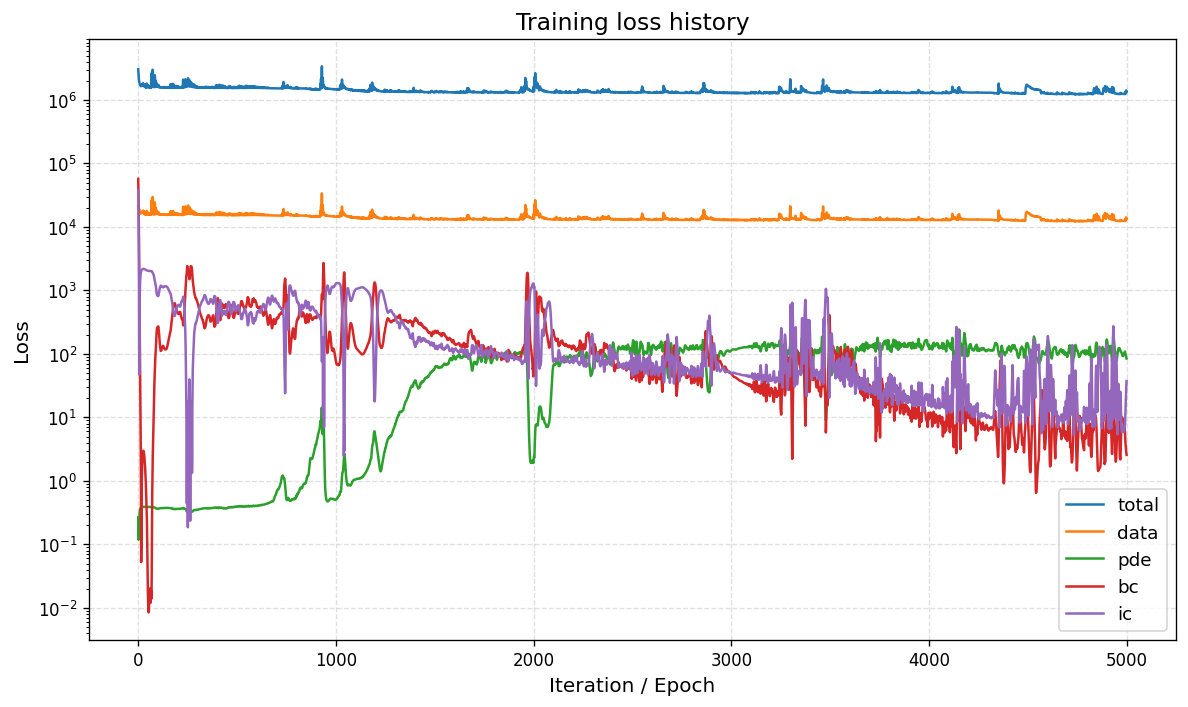

In [23]:
model = PINN_Mill()

# === 1ый этап - AdamW ===
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=500
)

history = []

history_total = []
history_pde = []
history_bc = []
history_ic = []
history_data = []
best_loss = float('inf')
epochs = 5000

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    t_real_train = t_real_train.detach().requires_grad_(True)
    z_real_train = z_real_train.detach().requires_grad_(True)

    t_pde = t_pde.detach().requires_grad_(True)
    z_pde = z_pde.detach().requires_grad_(True)

    t_bc = t_bc.detach().requires_grad_(True)
    z_bc = z_bc.detach().requires_grad_(True)

    t_ic = t_ic.detach().requires_grad_(True)
    z_ic = z_ic.detach().requires_grad_(True)


    loss, pde, bc, ic, data = total_loss(
        loss_pde(model, t_pde, z_pde, Fm_pde, Fl_pde),
        loss_bc(model, t_bc, z_bc, Fm_bc, Fl_bc, S_in_bc),
        loss_ic(model, t_ic, z_ic, Fm_ic, Fl_ic, eps0_ic, S0_ic), 
        loss_data(model, t_real_train, z_real_train, Fm_real_train, Fl_real_train, S_real_train),
        lambda_pde=1.0,
        lambda_bc=10.0,
        lambda_ic=10.0,
        lambda_data=100.0
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()
    scheduler.step(loss)

    history_total.append(loss.item())
    history_pde.append(pde.item())
    history_bc.append(bc.item())
    history_ic.append(ic.item())

    if torch.is_tensor(data):
        history_data.append(data.item())
    else:
        history_data.append(data)

    if loss.item() < best_loss:
        best_loss = loss.item()
        timestamp = datetime.now().strftime("%Y-%m-%d_%H")
        filename = f"best_pinn_{timestamp}.pt"
        torch.save(model.state_dict(), filename)

    if epoch % 100 == 0:

        print(
            f'Epoch {epoch:6d} | '
            f'Total={loss.item():.6f} | '
            f'PDE={pde.item():.6f} | '
            f'BC={bc.item():.6f} | '
            f'IC={ic.item():.6f} | '
            f'DATA={data.item():.6f}'
        )

loss_visualization()

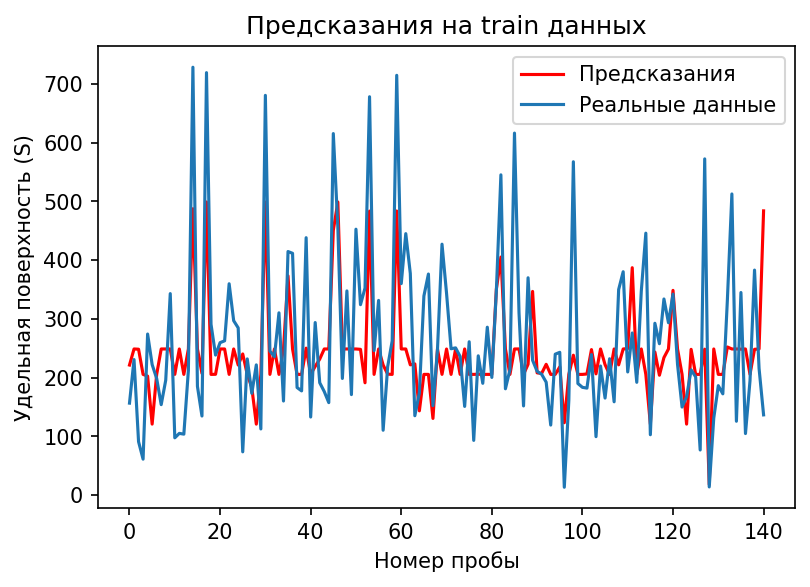

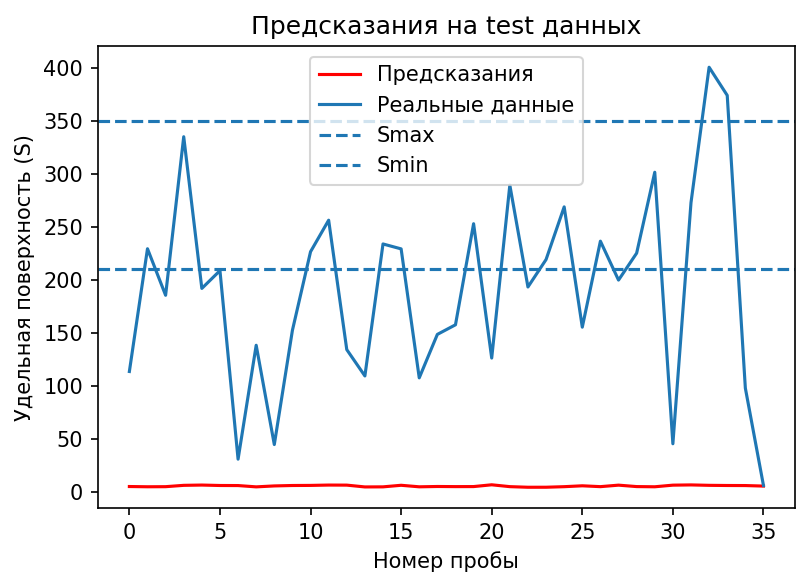

In [24]:
testing_vis()

## ann 2d

Epoch      0 | Total=20989.564453 | PDE=0.039906 | BC=57829.214844 | IC=38148.703125 | DATA=20989.564453
Epoch    100 | Total=15947.748047 | PDE=0.254307 | BC=17671.226562 | IC=7349.331543 | DATA=15947.748047
Epoch    200 | Total=16228.084961 | PDE=0.161259 | BC=13905.843750 | IC=4951.983398 | DATA=16228.084961
Epoch    300 | Total=15981.180664 | PDE=0.148937 | BC=12488.283203 | IC=4080.011963 | DATA=15981.180664
Epoch    400 | Total=15324.012695 | PDE=0.159669 | BC=9287.592773 | IC=2325.427002 | DATA=15324.012695
Epoch    500 | Total=15127.216797 | PDE=0.177110 | BC=8319.199219 | IC=1905.208008 | DATA=15127.216797
Epoch    600 | Total=16298.251953 | PDE=0.135444 | BC=18712.376953 | IC=8085.510254 | DATA=16298.251953
Epoch    700 | Total=14700.138672 | PDE=0.160852 | BC=1200.408569 | IC=150.916092 | DATA=14700.138672
Epoch    800 | Total=14835.872070 | PDE=0.209012 | BC=2295.114746 | IC=6.928704 | DATA=14835.872070
Epoch    900 | Total=14766.503906 | PDE=0.203724 | BC=1214.119263 | IC=

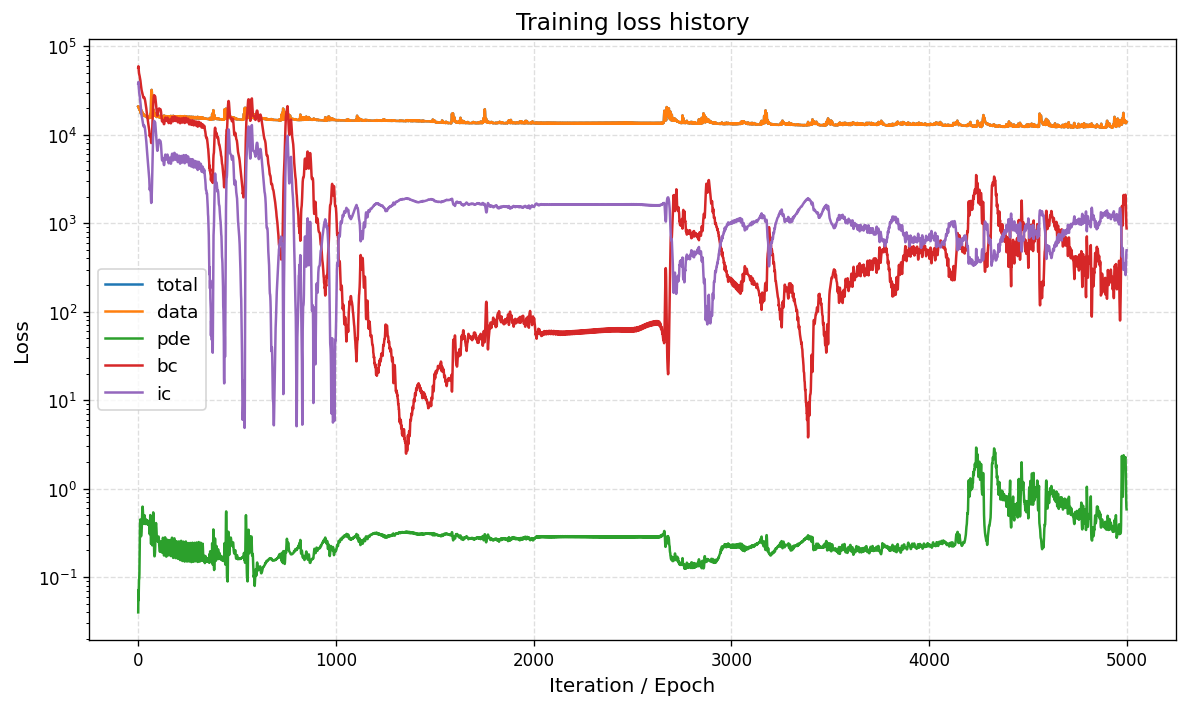

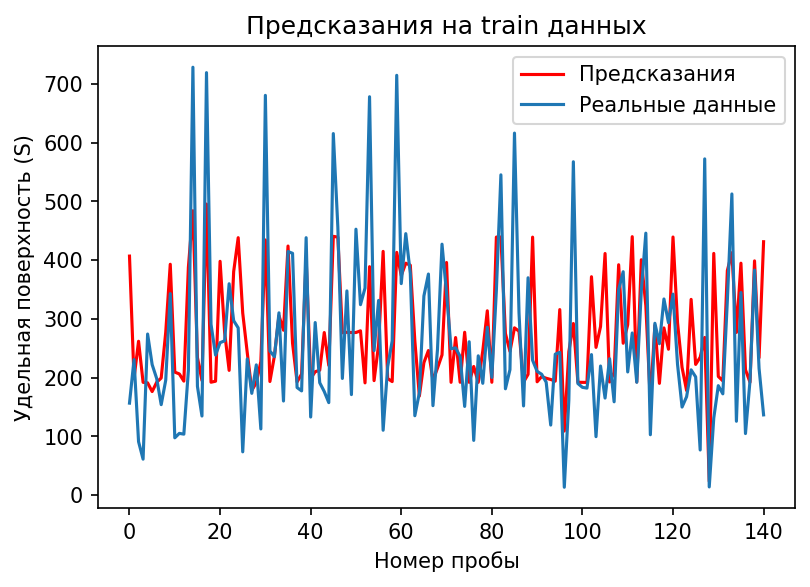

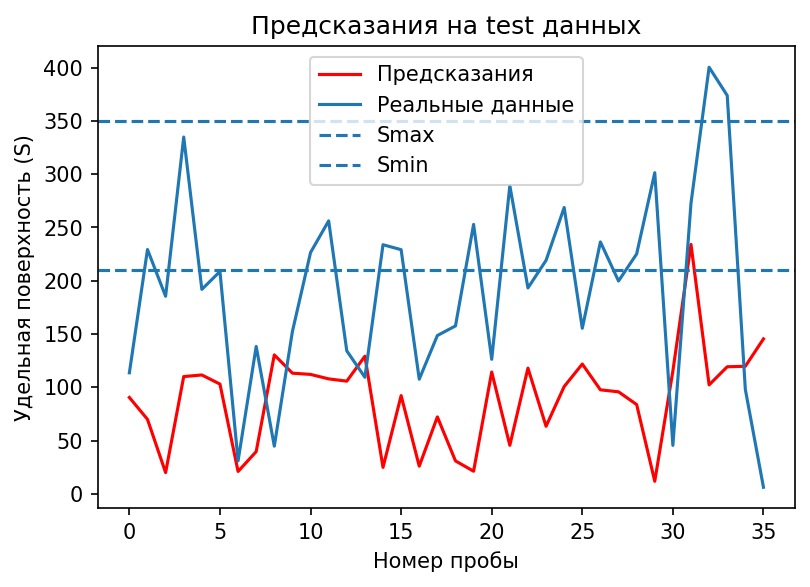

In [28]:
model = PINN_Mill()

# === 1ый этап - AdamW ===
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=500
)

history = []

history_total = []
history_pde = []
history_bc = []
history_ic = []
history_data = []
best_loss = float('inf')
epochs = 5000

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    t_real_train = t_real_train.detach().requires_grad_(True)
    z_real_train = z_real_train.detach().requires_grad_(True)

    t_pde = t_pde.detach().requires_grad_(True)
    z_pde = z_pde.detach().requires_grad_(True)

    t_bc = t_bc.detach().requires_grad_(True)
    z_bc = z_bc.detach().requires_grad_(True)

    t_ic = t_ic.detach().requires_grad_(True)
    z_ic = z_ic.detach().requires_grad_(True)


    loss, pde, bc, ic, data = total_loss(
        loss_pde(model, t_pde, z_pde, Fm_pde, Fl_pde),
        loss_bc(model, t_bc, z_bc, Fm_bc, Fl_bc, S_in_bc),
        loss_ic(model, t_ic, z_ic, Fm_ic, Fl_ic, eps0_ic, S0_ic), 
        loss_data(model, t_real_train, z_real_train, Fm_real_train, Fl_real_train, S_real_train),
        lambda_pde=0.0,
        lambda_bc=0.0,
        lambda_ic=0.0,
        lambda_data=1.0
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()
    scheduler.step(loss)

    history_total.append(loss.item())
    history_pde.append(pde.item())
    history_bc.append(bc.item())
    history_ic.append(ic.item())

    if torch.is_tensor(data):
        history_data.append(data.item())
    else:
        history_data.append(data)

    if loss.item() < best_loss:
        best_loss = loss.item()
        timestamp = datetime.now().strftime("%Y-%m-%d_%H")
        filename = f"best_pinn_{timestamp}.pt"
        torch.save(model.state_dict(), filename)

    if epoch % 100 == 0:

        print(
            f'Epoch {epoch:6d} | '
            f'Total={loss.item():.6f} | '
            f'PDE={pde.item():.6f} | '
            f'BC={bc.item():.6f} | '
            f'IC={ic.item():.6f} | '
            f'DATA={data.item():.6f}'
        )

loss_visualization()
testing_vis()

## 4d - with new data

Epoch      0 | Total=288657.531250 | PDE=0.109201 | BC=81154.828125 | IC=38615.554688 | DATA=20750.259766
Epoch    100 | Total=172605.937500 | PDE=0.348126 | BC=15809.260742 | IC=1415.121094 | DATA=15679.632812
Epoch    200 | Total=169072.078125 | PDE=0.832976 | BC=15434.746094 | IC=1648.517334 | DATA=15363.650391
Epoch    300 | Total=162704.234375 | PDE=0.885585 | BC=14871.009766 | IC=1574.069702 | DATA=14783.234375
Epoch    400 | Total=161952.375000 | PDE=0.894481 | BC=14782.718750 | IC=1676.083374 | DATA=14716.875977
Epoch    500 | Total=164658.921875 | PDE=1.044708 | BC=15009.782227 | IC=1794.484619 | DATA=14964.808594
Epoch    600 | Total=159104.640625 | PDE=1.184631 | BC=14482.400391 | IC=1986.003174 | DATA=14462.106445
Epoch    700 | Total=174097.437500 | PDE=1.019466 | BC=15868.955078 | IC=1791.781372 | DATA=15822.746094
Epoch    800 | Total=165219.578125 | PDE=1.021236 | BC=15053.338867 | IC=1854.086670 | DATA=15016.521484
Epoch    900 | Total=171480.156250 | PDE=1.104008 | BC

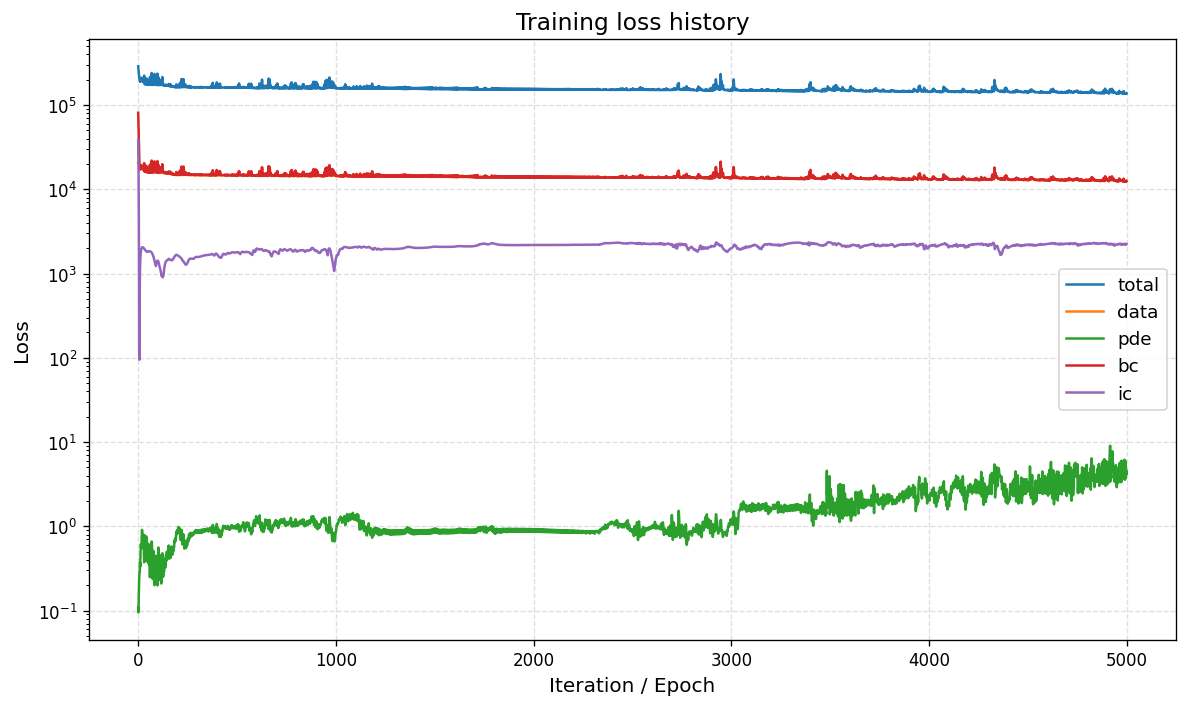

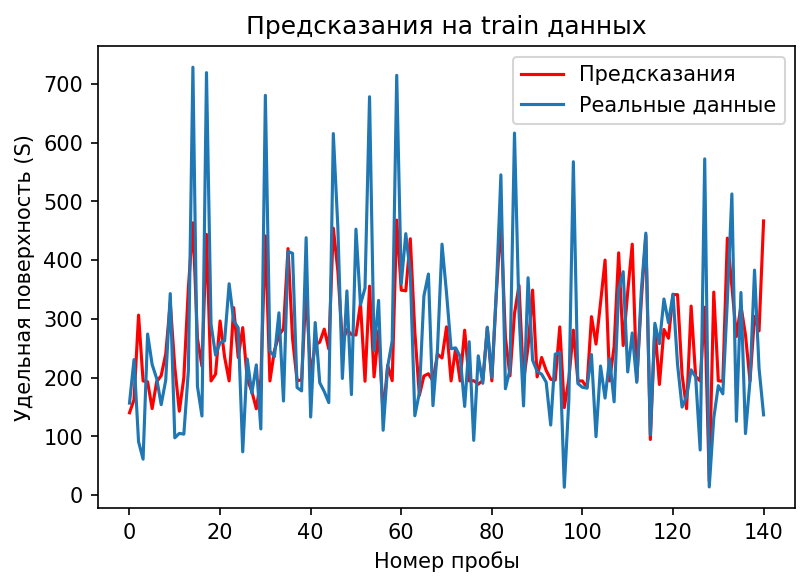

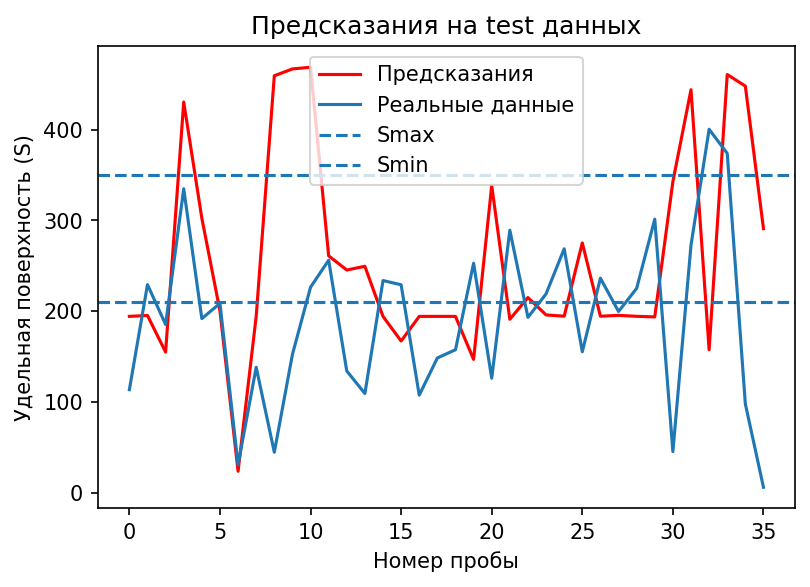

In [109]:
model = PINN_Mill()

# === 1ый этап - AdamW ===
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=500
)

history = []

history_total = []
history_pde = []
history_bc = []
history_ic = []
history_data = []
best_loss = float('inf')
epochs = 5000

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    t_real_train = t_real_train.detach().requires_grad_(True)
    z_real_train = z_real_train.detach().requires_grad_(True)

    t_pde = t_pde.detach().requires_grad_(True)
    z_pde = z_pde.detach().requires_grad_(True)

    t_bc = t_bc.detach().requires_grad_(True)
    z_bc = z_bc.detach().requires_grad_(True)

    t_ic = t_ic.detach().requires_grad_(True)
    z_ic = z_ic.detach().requires_grad_(True)


    loss, pde, bc, ic, data = total_loss(
        loss_pde(model, t_pde, z_pde, Fm_pde, Fl_pde),
        loss_bc(model, t_bc1, z_bc1, Fm_bc1, Fl_bc1, S_bc1) + loss_bc(model, t_bc2, z_bc2, Fm_bc2, Fl_bc2, S_bc2),
        loss_ic(model, t_ic, z_ic, Fm_ic, Fl_ic, eps0_ic, S0_ic), 
        loss_data(model, t_real_train, z_real_train, Fm_real_train, Fl_real_train, S_real_train),
        lambda_pde=1.0,
        lambda_bc=1.0,
        lambda_ic=0.0,
        lambda_data=10.0
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()
    scheduler.step(loss)

    history_total.append(loss.item())
    history_pde.append(pde.item())
    history_bc.append(bc.item())
    history_ic.append(ic.item())

    if torch.is_tensor(data):
        history_data.append(data.item())
    else:
        history_data.append(data)

    if loss.item() < best_loss:
        best_loss = loss.item()
        timestamp = datetime.now().strftime("%Y-%m-%d_%H")
        filename = f"best_pinn_{timestamp}.pt"
        torch.save(model.state_dict(), filename)

    if epoch % 100 == 0:

        print(
            f'Epoch {epoch:6d} | '
            f'Total={loss.item():.6f} | '
            f'PDE={pde.item():.6f} | '
            f'BC={bc.item():.6f} | '
            f'IC={ic.item():.6f} | '
            f'DATA={data.item():.6f}'
        )

loss_visualization()
testing_vis()

# testing

## 1st

In [112]:
model = PINN_Mill()
state_dict = torch.load('best_pinn_2026-06-06_17.pt', weights_only=True)
model.load_state_dict(state_dict)
model.eval()

PINN_Mill(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=2, bias=True)
  )
)

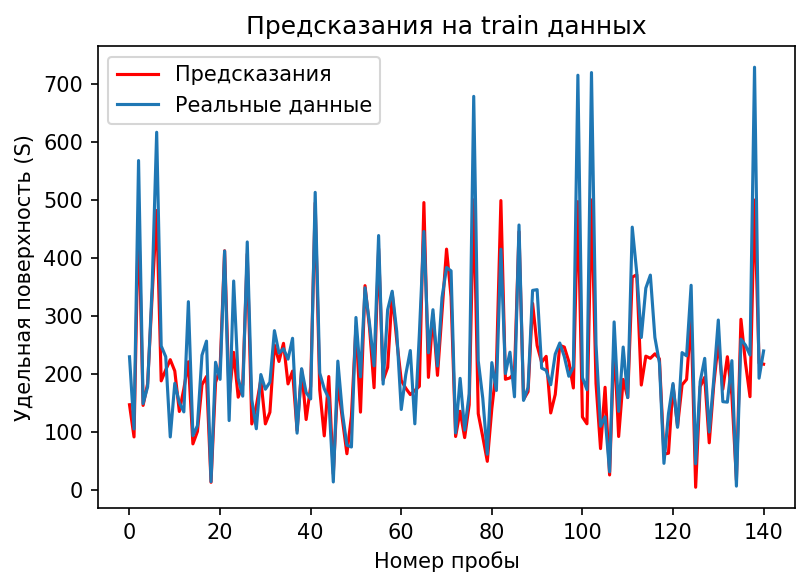

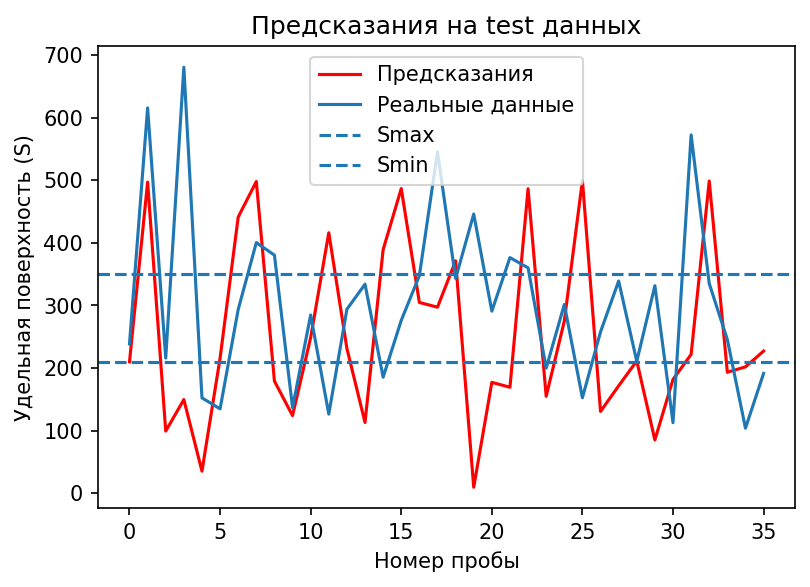

In [108]:
testing_vis()

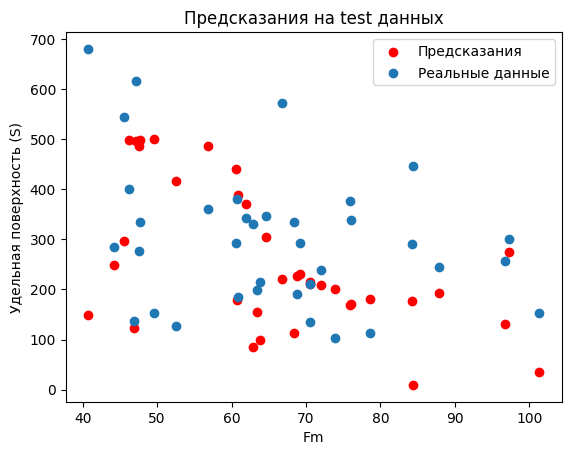

In [87]:
_, preds = model(t_real_test, z_real_test, Fm_real_test, Fl_real_test)
plt.scatter(Fm_real_test, preds.detach().numpy(), c='r', label='Предсказания')
plt.scatter(Fm_real_test, S_real_test, label='Реальные данные')
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Fm")
plt.legend()
plt.show()

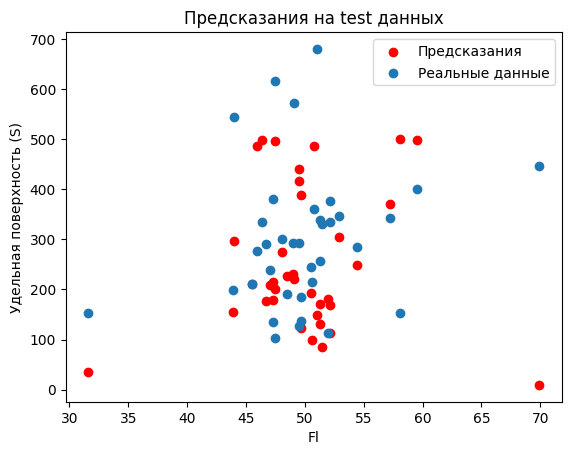

In [88]:
_, preds = model(t_real_test, z_real_test, Fm_real_test, Fl_real_test)
plt.scatter(Fl_real_test, preds.detach().numpy(), c='r', label='Предсказания')
plt.scatter(Fl_real_test, S_real_test, label='Реальные данные')
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Fl")
plt.legend()
plt.show()

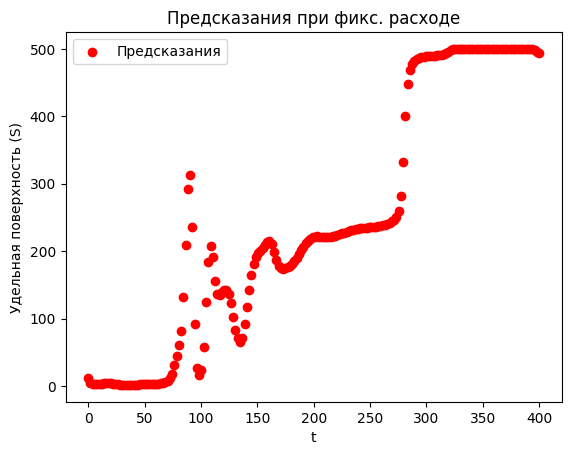

In [103]:
t = torch.linspace(0, 400, 200).reshape(-1, 1)
z = torch.linspace(0, 4.5, 200).reshape(-1, 1)

Fm = torch.full_like(t, 70.0)
Fl = torch.full_like(t, 40.0)

eps, S = model(t, z, Fm, Fl)
plt.scatter(t, S.detach().numpy(), c='r', label='Предсказания')
plt.title("Предсказания при фикс. расходе")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("t")
plt.legend()
plt.show()


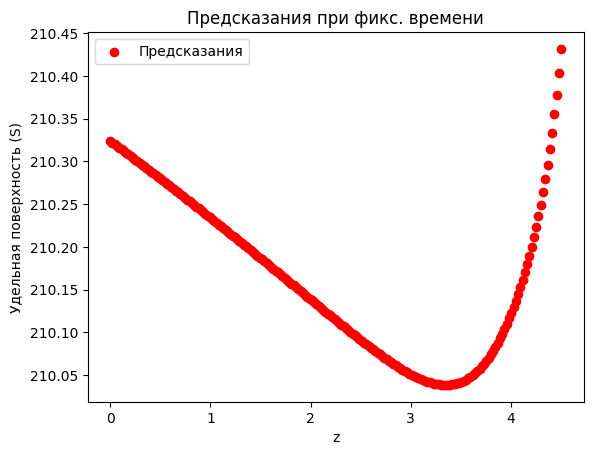

In [104]:
z = torch.linspace(0, 4.5, 200).reshape(-1, 1)

t = torch.full_like(z, 400.0)
Fm = torch.full_like(z, 120.0)
Fl = torch.full_like(z, 40.0)

eps, S = model(t, z, Fm, Fl)

eps, S = model(t, z, Fm, Fl)
plt.scatter(z, S.detach().numpy(), c='r', label='Предсказания')
plt.title("Предсказания при фикс. времени")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("z")
plt.legend()
plt.show()

In [100]:
data_periodic = pd.read_csv('periodic_selections.csv')

In [109]:
model = PINN_Mill()
state_dict = torch.load('best_pinn_mill.pt', weights_only=True)
model.load_state_dict(state_dict)
model.eval()

PINN_Mill(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [116]:
Fm = data_periodic["Q_bauxite_[t/h]"][100:].values.reshape(-1, 1)
Fl = data_periodic["Q_liquid_mill13_[m3/h]"][100:].values.reshape(-1, 1)
S = data_periodic["S_[m2/kg]"][100:].values.reshape(-1, 1)
Qs = Fm / Ore_Density
Ql = Fl / Liquid_Density

u = (Qs + Ql) / A_pulp

t = Mill_Length / (u + 1e-8)
z = z_real_train = torch.full(
    (len(Fm), 1),
    Mill_Length
)

## ann

In [140]:
model_ann = PINN_Mill()
state_dict = torch.load('best_ann_2026-06-07_11.pt', weights_only=True)
model.load_state_dict(state_dict)
model.eval()

PINN_Mill(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [25]:
model_ann = PINN_Mill()
state_dict = torch.load('best_ann_2026-06-07_11.pt', weights_only=True)
model_ann.load_state_dict(state_dict)
model_ann.eval()

model_pinn = PINN_Mill()
state_dict = torch.load('best_pinn_2026-06-06_17.pt', weights_only=True)
model_pinn.load_state_dict(state_dict)
model_pinn.eval()

PINN_Mill(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=2, bias=True)
  )
)

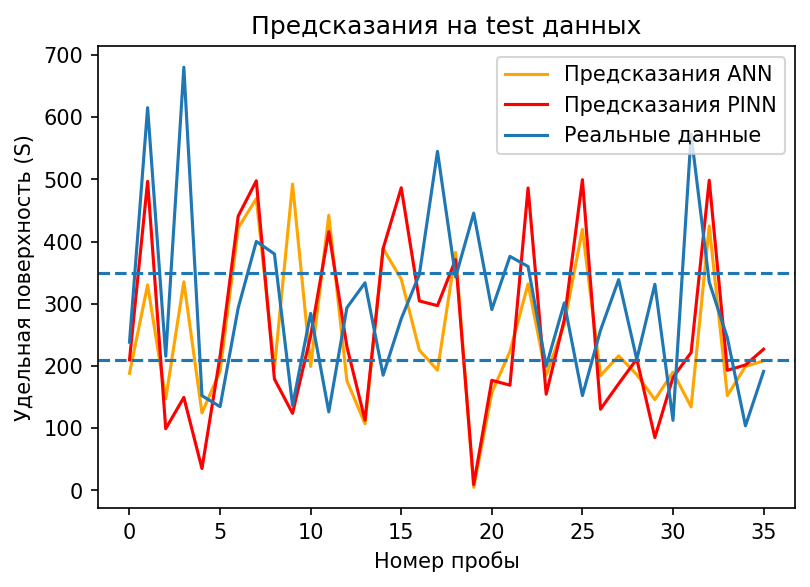

In [27]:
plt.figure(figsize=(6, 4), dpi=150)
_, preds_pinn = model_pinn(t_real_test, z_real_test, Fm_real_test, Fl_real_test)
_, preds_ann = model_ann(t_real_test, z_real_test, Fm_real_test, Fl_real_test)
plt.plot(preds_ann.detach().numpy(), c='orange', label='Предсказания ANN')
plt.plot(preds_pinn.detach().numpy(), c='red', label='Предсказания PINN')
plt.plot(S_real_test, label='Реальные данные')
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.axhline(350, linestyle='--')

plt.axhline(210, linestyle='--')
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

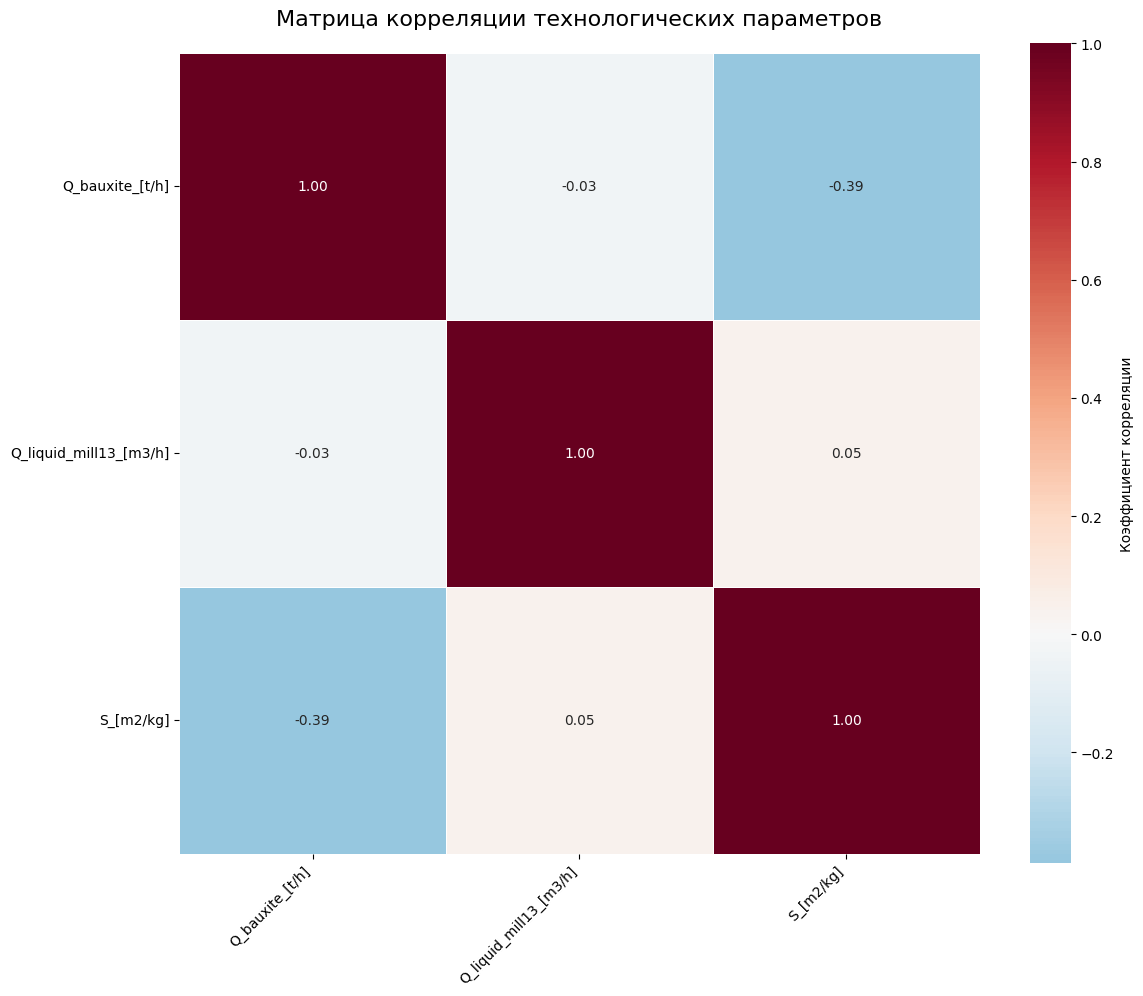

In [ ]:
features = [
    "Q_bauxite_[t/h]",
    "Q_liquid_mill13_[m3/h]",
    "S_[m2/kg]"
]

corr = df[features].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Коэффициент корреляции"}
)

plt.title(
    "Матрица корреляции технологических параметров",
    fontsize=16,
    pad=20
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## confusion matrix

In [63]:
LOW = 200
HIGH = 350

In [64]:
# обычный


# расширенный
real_out = (S_real_test < LOW) | (S_real_test > HIGH)
n_real_out = real_out.sum()
n_real_in = (~real_out).sum()
print(f'Выходов за пределы: {n_real_out}')
print(f'В пределах нормы: {n_real_in}')
print('-'*30)

# пинн
pinn_out = (preds_pinn < LOW) | (preds_pinn > HIGH)
n_pinn_out = pinn_out.sum()
n_pinn_in = (~pinn_out).sum()
print(f'PINN считает выходов: {n_pinn_out}')
print(f'В пределах нормы: {n_pinn_in}')
print('-'*30)

# ann
ann_out = (preds_ann < LOW) | (preds_ann > HIGH)
n_ann_out = ann_out.sum()
n_ann_in = (~ann_out).sum()
print(f'ANN считает выходов: {n_ann_out}')
print(f'В пределах нормы: {n_ann_in}')

Выходов за пределы: 19
В пределах нормы: 17
------------------------------
PINN считает выходов: 25
В пределах нормы: 11
------------------------------
ANN считает выходов: 27
В пределах нормы: 9


# train final

In [142]:
model_pinn = PINN_Mill()
state_dict = torch.load('best_pinn_2026-06-06_17.pt', weights_only=True)
model_pinn.load_state_dict(state_dict)
model_pinn.eval()

PINN_Mill(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=2, bias=True)
  )
)

Epoch      0 | Total=519120.218750 | PDE=1.175155 | BC=16.963398 | IC=1669.846680 | DATA=5022.509277


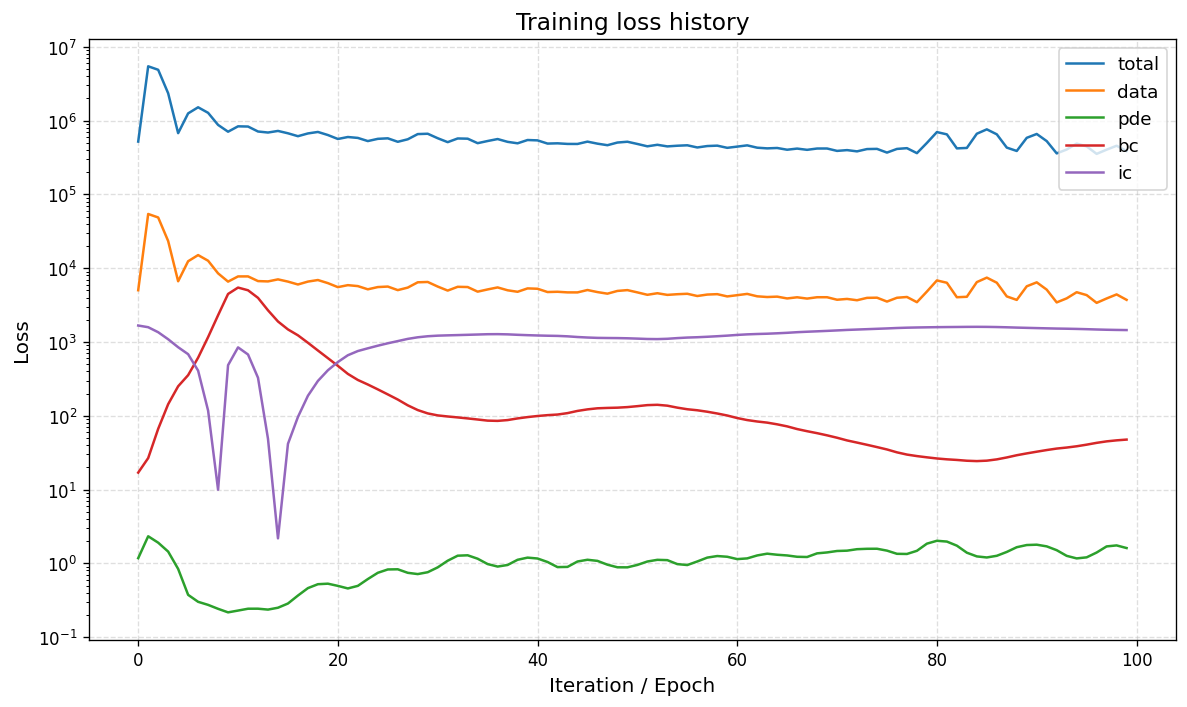

In [138]:
# === 1ый этап - AdamW ===
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=500
)

history = []

history_total = []
history_pde = []
history_bc = []
history_ic = []
history_data = []
best_loss = float('inf')
epochs = 100

for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()

    t_real_train = t_real_test.detach().requires_grad_(True)
    z_real_train = z_real_test.detach().requires_grad_(True)

    t_pde = t_pde.detach().requires_grad_(True)
    z_pde = z_pde.detach().requires_grad_(True)

    t_bc = t_bc.detach().requires_grad_(True)
    z_bc = z_bc.detach().requires_grad_(True)

    t_ic = t_ic.detach().requires_grad_(True)
    z_ic = z_ic.detach().requires_grad_(True)


    loss, pde, bc, ic, data = total_loss(
        loss_pde(model, t_pde, z_pde, Fm_pde, Fl_pde),
        loss_bc(model, t_bc, z_bc, Fm_bc, Fl_bc, S_in_bc),
        loss_ic(model, t_ic, z_ic, Fm_ic, Fl_ic, eps0_ic, S0_ic), 
        loss_data(model, t_real_test, z_real_test, Fm_real_test, Fl_real_test, S_real_test),
        lambda_pde=1.0,
        lambda_bc=10.0,
        lambda_ic=10.0,
        lambda_data=100.0
    )

    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0
    )

    optimizer.step()
    scheduler.step(loss)

    history_total.append(loss.item())
    history_pde.append(pde.item())
    history_bc.append(bc.item())
    history_ic.append(ic.item())

    if torch.is_tensor(data):
        history_data.append(data.item())
    else:
        history_data.append(data)

    if loss.item() < best_loss:
        best_loss = loss.item()
        timestamp = datetime.now().strftime("%Y-%m-%d_%H")
        filename = f"best_pinn_{timestamp}.pt"
        torch.save(model.state_dict(), filename)

    if epoch % 100 == 0:

        print(
            f'Epoch {epoch:6d} | '
            f'Total={loss.item():.6f} | '
            f'PDE={pde.item():.6f} | '
            f'BC={bc.item():.6f} | '
            f'IC={ic.item():.6f} | '
            f'DATA={data.item():.6f}'
        )

loss_visualization()

In [128]:
df['average_time']

0      2023-01-03 08:42:30
1      2023-01-03 12:16:30
2      2023-01-03 15:03:00
3      2023-01-06 09:04:00
4      2023-01-06 11:33:30
              ...         
172    2023-12-09 10:51:30
173    2023-12-09 11:46:00
174    2023-12-09 15:25:00
175    2023-12-09 16:25:00
176    2023-12-09 17:15:00
Name: average_time, Length: 177, dtype: str

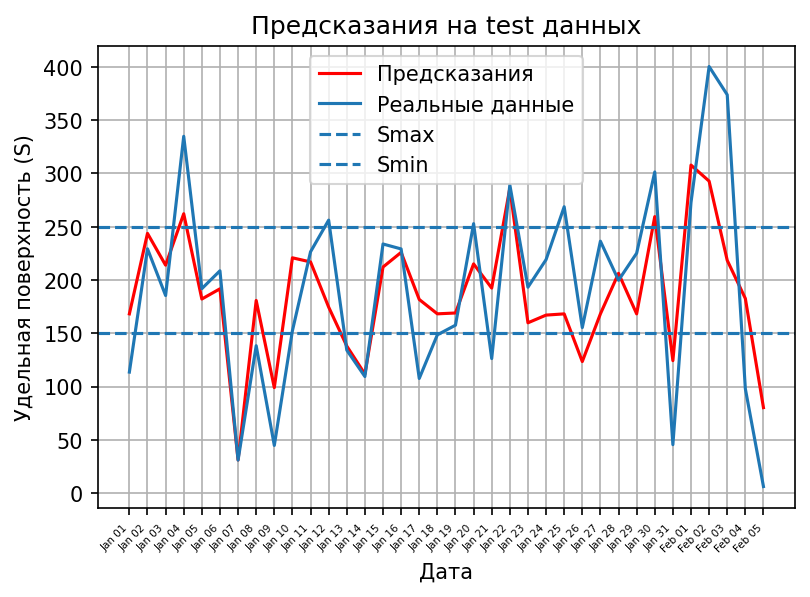

In [ ]:
_, preds = model(t_real_test, z_real_test, Fm_real_test, Fl_real_test)
plt.figure(figsize=(6, 4), dpi=150)
plt.plot(average_time_train, preds.detach().numpy(), c='r', label='Предсказания')
plt.plot(average_time_train, S_real_test, label='Реальные данные')

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))  # или '%b %d' для 'May 15'
# Поворот подписей на 45 градусов
plt.xticks(rotation=45, ha='right', fontsize=5)

plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.axhline(250,
        linestyle='--', label='Smax')

plt.axhline(150,
        linestyle='--', label='Smin')
plt.xlabel("Дата")
plt.grid()
plt.legend()
plt.show()